## fmuritalClustering.ipynb
## Unsupervised Learning: K-Means Clustering & Dimension Reduction Using PCA
## Use Case: Identifying Topics from Articles on The Same Topic
## Faruk Muritala
## Sep 15 2023

In [1]:
# Section 1: Import the 'getpass' function from the 'getpass' module to securely input sensitive information like API tokens

from getpass import getpass


In [2]:
# Section 2: Import OS and Install Necessary Packages

# Import the 'os' module to interact with the operating system
import os

# Import the 'numpy' library for numerical operations
import numpy as np

# Install necessary packages using pip
# - 'langchain' for language processing
# - 'sentence_transformers' for working with sentence embeddings
# - 'chromadb' for working with vector stores
# - 'transformers', 'sentencepiece', and 'sacremoses' for language model support
!pip install langchain
!pip install sentence_transformers
!pip install chromadb
!pip install transformers sentencepiece sacremoses


In [3]:
# Section 3: Set Up API Token

# Prompt the user to securely input their Hugging Face API token using 'getpass'
HUGGINGFACEHUG_API_TOKEN = getpass()

# Set the API token in the environment variable for later use
os.environ["HUGGINGFACEHUG_API_TOKEN"] = HUGGINGFACEHUG_API_TOKEN


··········


In [4]:
# Section 4: Import Libraries and Modules for Text Processing and Analysis

# Import necessary modules and classes for text processing and analysis
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import WebBaseLoader
from langchain import HuggingFaceHub
from langchain import PromptTemplate, LLMChain
from langchain.indexes import VectorstoreIndexCreator
from langchain.embeddings import HuggingFaceEmbeddings

# Import PCA (Principal Component Analysis) from the scikit-learn library for dimensionality reduction
from sklearn.decomposition import PCA


In [5]:
# Section 5: Data Collection

# Define a list of article URLs to collect data from
article_urls = [
    "https://www.tandfonline.com/doi/abs/10.1080/08982119608919047?journalCode=lqen20",
    "https://www.tandfonline.com/doi/abs/10.1080/00224065.1992.11979403",
    "https://link.springer.com/chapter/10.1007/978-3-319-41582-6_2",
    "https://link.springer.com/article/10.1007/s00500-018-3614-y",
    "https://www.emerald.com/insight/content/doi/10.1108/TQM-03-2013-0036/full/html?casa_token=sCWH_7yuz7gAAAAA:NMwTaC1356meOPMIFyrj8fVClZsyYFLbRL0YGJ44_MXGvZmRfcsNgA9P2GCa-J9NR0pjoNvov5MkMNn3OvxZpjYl6x77OxwH4WnrOrVFlBPtbgEBImM"
]

# Create a WebBaseLoader and load data from the specified article URLs
loader = WebBaseLoader(article_urls)
data = loader.load()


In [6]:
# Section 6: Text Splitting


# Step 4: Text Splitting
# Create a RecursiveCharacterTextSplitter for splitting text into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=20)

# Splitting the documents into smaller overlapping fixed-sized segments
all_splits = text_splitter.split_documents(data)


In [7]:
# Section 7: Vectorstore Creation

# Step 5: Vectorstore Creation
# Note: If using the OpenAIEmbeddings, change embedding to OpenAIEmbeddings in the Vector store
# from langchain.embeddings import OpenAIEmbeddings

from langchain.vectorstores import Chroma

# Create a list of IDs for the documents
ids = [str(i) for i in range(1, len(all_splits) + 1)]

# Create a Chroma vector store from the preprocessed text segments using HuggingFaceEmbeddings
vectorstore = Chroma.from_documents(documents=all_splits, embedding=HuggingFaceEmbeddings(), ids=ids)


In [8]:
# Section 8: Checking Individual IDs and Result

# Checking for individual IDs
# You can uncomment and use this line to check a specific ID's embeddings, documents, and metadata.
# print(vectorstore._collection.get(ids=[ids[20]], include=['embeddings', 'documents', 'metadatas']))

# Retrieving all results including embeddings, documents, and metadata
result = vectorstore._collection.get(include=['embeddings', 'documents', 'metadatas'])


In [9]:
# Ensure that vectorstore.embeddings is converted to a numeric array
# Assuming vectorstore.embeddings is a list of embeddings

# Convert the list of embeddings to a numeric array
embeddings_array = np.array(list(result['embeddings']))

#Uncomment to Print the first 500 elements of the embeddings array
#print(embeddings_array[0:500])


[[-0.01534229  0.00569351  0.00977636 ...  0.03472372 -0.05377874
   0.02749155]
 [-0.01534229  0.00569351  0.00977636 ...  0.03472372 -0.05377874
   0.02749155]
 [-0.08593275 -0.01013931 -0.0411475  ... -0.03700462 -0.06025186
   0.03185935]
 ...
 [-0.06949441 -0.05352916 -0.01863075 ...  0.00154415 -0.02322987
   0.02075522]
 [ 0.0541116   0.0089971  -0.02572099 ...  0.03152414 -0.03057885
  -0.00944462]
 [-0.00723746  0.07965329 -0.01661789 ...  0.03626389  0.00319047
   0.02330465]]


In [10]:
# Section 9: Dimensionality Reduction with PCA

# Step 6: Dimensionality Reduction with PCA
n_components = 3  # Choose the number of principal components
pca = PCA(n_components=n_components)

# Performing PCA on the embeddings array to reduce dimensionality
reduced_embeddings = pca.fit_transform(embeddings_array)


In [34]:
# Customized K-Means Algorithm using Manhattan Distance
class CustomKMeans:
    def __init__(self, k=3):
        self.k = k
        self.centroids = None

    def manhattan_distance(data_point, centroids):
        return (np.sum(np.abs(centroids - data_point) , axis=1))

    def fit(self, X, max_iterations=200):
        # Initialize centroids randomly within the dataset
        self.centroids = X[np.random.choice(X.shape[0], size=self.k, replace=False)]

        for _ in range(max_iterations):
            # Assigning each data point to the nearest centroid
            distances = np.array([CustomKMeans.manhattan_distance(x, self.centroids) for x in X])
            cluster_labels = np.argmin(distances, axis=1)

            # Update centroids based on mean of assigned data points
            new_centroids = np.array([X[cluster_labels == i].mean(axis=0) for i in range(self.k)])

            # Check for convergence, rtol = tolerance level
            if np.allclose(self.centroids, new_centroids, rtol=1e-4):
                break

            self.centroids = new_centroids

        return cluster_labels

# Step 7: K-Means Clustering with our Custom Algorithm
k = 5  # Choose the number of clusters
custom_kmeans = CustomKMeans(k)
cluster_labels = custom_kmeans.fit(reduced_embeddings)


In [35]:
# Section 11: Printing Cluster Labels and Centroids

# Step 8: Printing Cluster Labels and Centroids

# Print cluster labels
print("Cluster Labels:")
print(cluster_labels)

# Print cluster centroids
print("Cluster Centroids:")
print(custom_kmeans.centroids)


Cluster Labels:
[1 1 2 2 2 2 2 1 1 1 0 0 0 0 2 2 2 2 2 2 4 0 2 0 0 1 1 1 1 1 1 3 3 1 2 3 3
 4 3 3 3 2 0 3 3 3 3 2 3 3 0 1 1 4 1 3 3 0 3 3 1 1 0 4 1 1 2 1 1 2 2 4 0 0
 2 4 2 4 2 2 1 4]
Cluster Centroids:
[[ 0.00866604  0.38943574 -0.15410384]
 [ 0.45703426 -0.0761878   0.05431691]
 [-0.35712958 -0.14555719 -0.18767277]
 [-0.32168685  0.05903252  0.33704069]
 [ 0.39476439 -0.14847846 -0.09906411]]


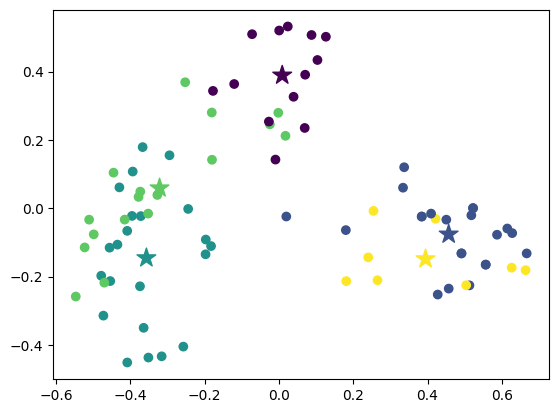

In [36]:
# Section 12: Visualizing the Clusters

# Step 9: Visualizing the Clusters
import matplotlib.pyplot as plt  # Import Matplotlib

# Scatter plot the data points with colors based on cluster labels
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=cluster_labels)

# Scatter plot the centroids with '*' markers and different colors
# The 's=200' parameter controls the size of the markers
plt.scatter(custom_kmeans.centroids[:, 0], custom_kmeans.centroids[:, 1], c=range(len(custom_kmeans.centroids)), marker="*", s=200)

# Display the plot
plt.show()


In [37]:
# Section 13: Tracing Clusters to embeddings

# Step 10: Restructuring the data points to clarify the actual clusters with their embeddings
# Initialize a dictionary to store cluster information
Emb_dict = {}

# Iterating through data points and cluster labels
for i in range(len(reduced_embeddings)):
    # Initializing a temporary dictionary for each data point
    Emb_temp = {}
    Emb_temp[i] = reduced_embeddings[i]

    # Check if the cluster label already exists in the dictionary
    if Emb_dict.get(cluster_labels[i]) is not None:
        # If yes, update the existing cluster information
        Emb_dict[cluster_labels[i]].update(Emb_temp)
    else:
        # If no, create a new entry for the cluster
        Emb_dict[cluster_labels[i]] = Emb_temp

# Print the cluster information
print(Emb_dict)

# Example: Accessing keys of cluster 2
print(Emb_dict[2].keys())


{1: {0: array([ 0.38443548, -0.02430476,  0.09951952]), 1: array([ 0.38443548, -0.02430476,  0.09951952]), 7: array([ 0.66710053, -0.13228127, -0.01520912]), 8: array([5.22639813e-01, 3.74162839e-04, 1.48369699e-01]), 9: array([ 0.61488899, -0.05932994, -0.00142475]), 25: array([ 0.51809007, -0.02057699, -0.06467383]), 26: array([ 0.58724896, -0.07757101, -0.00434458]), 27: array([5.22639813e-01, 3.74162839e-04, 1.48369699e-01]), 28: array([ 0.62812701, -0.07283111, -0.01960236]), 29: array([ 0.55676835, -0.16516243, -0.00318313]), 30: array([ 0.49145257, -0.1322019 ,  0.01899138]), 33: array([ 0.01966207, -0.02420625,  0.09168638]), 51: array([0.33405988, 0.0601888 , 0.13242567]), 52: array([ 0.45065807, -0.03344542,  0.06127838]), 54: array([ 0.18004539, -0.06399114,  0.04569075]), 60: array([0.33710115, 0.12004827, 0.03250723]), 61: array([ 0.40960999, -0.01567513,  0.04538462]), 64: array([ 0.55676835, -0.16516243, -0.00318313]), 65: array([ 0.49145257, -0.1322019 ,  0.01899138]), 

In [26]:
# Section 14: Fetching Information of the closest points to their cluster in Vector Documentation

# Initialize a list to store the closest points and their information
closest_points_info = []

# Get the unique cluster labels
unique_clusters = np.unique(cluster_labels)

# Sort clusters by the number of data points in each cluster (descending order)
cluster_sizes = [(cluster, np.sum(cluster_labels == cluster)) for cluster in unique_clusters]
cluster_sizes.sort(key=lambda x: -x[1])

# Select the top 3 clusters
top_clusters = cluster_sizes[:3]

# Iterate through the top # 0f clusters
for cluster, _ in top_clusters:
    cluster_indices = np.where(cluster_labels == cluster)[0]  # Indices of data points in the cluster
    cluster_data = reduced_embeddings[cluster_indices]  # Data points in the cluster
    centroid = custom_kmeans.centroids[cluster]  # Centroid of the cluster

    # Calculate the Euclidean distances between all data points in the cluster and the centroid
    distances = np.linalg.norm(cluster_data - centroid, axis=1)

    # Find the index of the data point with the minimum distance
    closest_index = np.argmin(distances)

    # Get the closest data point
    closest_data_point = cluster_data[closest_index]

    # Get the ID of the closest data point in reduced_embeddings
    closest_data_point_id = cluster_indices[closest_index]

    # Get the actual ID in the vectorstore (assuming 'ids' is a list of IDs corresponding to data points)
    vectorstore_id = ids[closest_data_point_id]

    # Get the text associated with the data point from the vectorstore
    split_text = vectorstore._collection.get(ids=[vectorstore_id], include=['documents'])['documents'][0]

    # Append the cluster, closest data point, its ID in reduced_embeddings, actual vectorstore ID, and text
    closest_points_info.append((cluster, closest_data_point, closest_data_point_id, vectorstore_id, split_text))

# The 'closest_points_info' list now contains the information for the closest points in the top # clusters,
# including their actual IDs in the vectorstore and associated text.


In [27]:
# The 'closest_points_info' list now contains the information for the closest points in the top # of clusters
closest_points_info[0][4]


'Accessibility statement\n\n\nTerms and conditions\n\n\nPrivacy policy\n\n\nHelp and support\n\n\n\n\n\n34.90.10.111\n\nNot affiliated\n\n\n\n\n© 2023 Springer Nature'

In [17]:
# Section 15: Initializing Pegasus Transformer Model and Tokenizer
#!pip install transformers sentencepiece sacremoses

#Importing everything from transformers library:
from transformers import *


/usr/local/lib/python3.10/dist-packages/transformers/deepspeed.py:23: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation_utils.py:24: FutureWarning: Importing `GenerationMixin` from `src/transformers/generation_utils.py` is deprecated and will be removed in Transformers v5. Import as `from transformers import GenerationMixin` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation_tf_utils.py:24: FutureWarning: Importing `TFGenerationMixin` from `src/transformers/generation_tf_utils.py` is deprecated and will be removed in Transformers v5. Import as `from transformers import TFGenerationMixin` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation_flax_utils.py:24: FutureWarning: Importing `FlaxGenerationMixin` from `sr

In [28]:
#Pegasus Transformer

model = PegasusForConditionalGeneration.from_pretrained("tuner007/pegasus_paraphrase")
tokenizer = PegasusTokenizerFast.from_pretrained("tuner007/pegasus_paraphrase")

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--tuner007--pegasus_paraphrase/snapshots/0159e2949ca73657a2f1329898f51b7bb53b9ab2/config.json
Model config PegasusConfig {
  "activation_dropout": 0.1,
  "activation_function": "relu",
  "add_bias_logits": false,
  "add_final_layer_norm": true,
  "architectures": [
    "PegasusForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "classif_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 16,
  "decoder_start_token_id": 0,
  "dropout": 0.1,
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 16,
  "eos_token_id": 1,
  "extra_pos_embeddings": 1,
  "force_bos_token_to_be_generated": false,
  "forced_eos_token_id": 1,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "init_std": 0.02,
  "is_encoder_

In [29]:
# Section 16: Getting Paraphrased Sentences

def get_paraphrased_sentences(model, tokenizer, sentence, num_return_sequences=5, num_beams=5):
  # tokenize the text to be form of a list of token IDs
  inputs = tokenizer([sentence], truncation=True, padding="longest", return_tensors="pt")
  # generate the paraphrased sentences
  outputs = model.generate(
    **inputs,
    num_beams=num_beams,
    num_return_sequences=num_return_sequences,
  )
  # decode the generated sentences using the tokenizer to get them back to text
  return tokenizer.batch_decode(outputs, skip_special_tokens=True)

In [30]:
# Section 17: Printing Paraphrased Sentences
for i in range(len(closest_points_info)):
  Rephrase_text= get_paraphrased_sentences(model, tokenizer, closest_points_info[i][4], num_beams=10, num_return_sequences=10)
  print(Rephrase_text)

Generate config GenerationConfig {
  "_from_model_config": true,
  "bos_token_id": 0,
  "decoder_start_token_id": 0,
  "eos_token_id": 1,
  "forced_eos_token_id": 1,
  "length_penalty": 0.8,
  "max_length": 60,
  "num_beams": 8,
  "pad_token_id": 0,
  "transformers_version": "4.33.2"
}

Generate config GenerationConfig {
  "_from_model_config": true,
  "bos_token_id": 0,
  "decoder_start_token_id": 0,
  "eos_token_id": 1,
  "forced_eos_token_id": 1,
  "length_penalty": 0.8,
  "max_length": 60,
  "num_beams": 8,
  "pad_token_id": 0,
  "transformers_version": "4.33.2"
}



['Privacy policy Help and support is not affiliated with Springer Nature.', 'Privacy policy Help and support not affiliated with Springer Nature', 'Privacy policy Help and support not affiliated with Springer Nature.', 'Privacy policy and help and support are not affiliated with Springer Nature.', 'Privacy policy Help and support is not affiliated with Springer Nature', 'Privacy policy Help and support 34.90.10.111 is not affiliated with Springer Nature.', 'Help and support is not affiliated with Springer Nature.', 'Privacy policy Help and support 34.9010.111 is not affiliated with Springer Nature.', 'Privacy policy Help and support is affiliated with Springer Nature.', 'Privacy policy Help and support 34.90.10.111 is not affiliated with Springer Nature']


Generate config GenerationConfig {
  "_from_model_config": true,
  "bos_token_id": 0,
  "decoder_start_token_id": 0,
  "eos_token_id": 1,
  "forced_eos_token_id": 1,
  "length_penalty": 0.8,
  "max_length": 60,
  "num_beams": 8,
  "pad_token_id": 0,
  "transformers_version": "4.33.2"
}



['There is a sample standard deviation for fuzzy data Rights and Permissions.', 'There is a sample standard deviation for fuzzy data.', 'There is a sample standard deviation for fuzzy data rights and permission.', 'Sample standard deviation for fuzzy data Rights and Permissions.', 'Sample standard deviation for fuzzy data Rights and Permissions is an article.', 'Sample standard deviation for fuzzy data Rights and Permissions', 'There is a sample standard deviation for fuzzy data Rights and permissions.', 'The sample standard deviation for fuzzy data Rights and Permissions is described in this article.', 'There is a sample standard deviation for fuzzy data Rights and permission.', ': Sample standard deviation for fuzzy data Rights and Permissions']
['The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve location and dispersion predictions.', 'The reconstructed Cp, Cpk, Cpm and Cpmk can be used to improve location and dispersion predictions.', 'The reconstructed Cp, Cpk, Cpm and Cp

In [21]:
############################## END OF CODE SECTION ######################################

## REPORT FOR  k values (3, 5, 10). at different PCA (3, 7, 19)

For Cluster 3
K-means= 3

Rephrase text:
['Pearn, W.L., Lin, P.C. tested process performance based on capability index (C_pk) with critical values.', 'Pearn, W.L. and Lin, P.C. tested process performance based on capability index (C_pk) with critical values.', 'Pearn, W.L., and Lin, P.C. tested process performance based on capability index (C_pk) with critical values.', 'Pearn, W.L., Lin, P.C., tested process performance based on capability index (C_pk) with critical values.', 'Pearn, W.L., Lin, P.C. tested process performance based on capability index (C_pk) with critical values', 'Pearn, W.L., Lin, P.C. tested process performance based on capability index  (C_pk) with critical values.', 'Pearn, W.L. and Lin, P.C. tested process performance based on capability index  (C_pk) with critical values.', 'Pearn, W.L., and Lin, P.C., tested process performance based on capability index (C_pk) with critical values.', 'Pearn, W.L. and Lin, P.C. tested process performance based on capability index (C_pk) with critical values', 'Pearn, W.L., and Lin, P.C. tested process performance based on capability index  (C_pk) with critical values.']

['There is a sample standard deviation for fuzzy data Rights and Permissions.', 'There is a sample standard deviation for fuzzy data.', 'There is a sample standard deviation for fuzzy data rights and permission.', 'Sample standard deviation for fuzzy data Rights and Permissions.', 'Sample standard deviation for fuzzy data Rights and Permissions is an article.', 'Sample standard deviation for fuzzy data Rights and Permissions', 'There is a sample standard deviation for fuzzy data Rights and permissions.', 'The sample standard deviation for fuzzy data Rights and Permissions is described in this article.', 'There is a sample standard deviation for fuzzy data Rights and permission.', ': Sample standard deviation for fuzzy data Rights and Permissions']




For Cluster 3
K-means= 5

Rephrase text:

['There is a sample standard deviation for fuzzy data Rights and Permissions.', 'There is a sample standard deviation for fuzzy data.', 'There is a sample standard deviation for fuzzy data rights and permission.', 'Sample standard deviation for fuzzy data Rights and Permissions.', 'Sample standard deviation for fuzzy data Rights and Permissions is an article.', 'Sample standard deviation for fuzzy data Rights and Permissions', 'There is a sample standard deviation for fuzzy data Rights and permissions.', 'The sample standard deviation for fuzzy data Rights and Permissions is described in this article.', 'There is a sample standard deviation for fuzzy data Rights and permission.', ': Sample standard deviation for fuzzy data Rights and Permissions']


['The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve location and dispersion predictions.', 'The reconstructed Cp, Cpk, Cpm and Cpmk can be used to improve location and dispersion predictions.', 'The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve location and dispersion predictions by introducing robust estimators such as the median and the interquartile range.', 'The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve location and dispersion predictions by introducing robust estimators such as the median and interquartile range.', 'The four popular Cp, Cpk, Cpm and Cpmk are reconstructed to improve location and dispersion predictions by introducing robust estimators such as the median and the interquartile range.', 'The reconstructed Cp, Cpk, Cpm, and Cpmk are used to improve location and dispersion predictions.', 'The reconstructed Cp, Cpk, Cpm and Cpmk will improve location and dispersion predictions by introducing robust estimators such as the median and the interquartile range.', 'The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve dispersion and location predictions.', 'The reconstructed Cp, Cpk, Cpm and Cpmk will improve location and dispersion predictions by introducing robust estimators such as the median and interquartile range.', 'The reconstructed Cp, Cpk, Cpm and Cpmk are used to improve location and dispersion predictions by introducing robust estimates such as the median and interquartile range.']



For Cluster 3
K-means= 10

Rephrase text:
['Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal.', 'Title Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint"', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-454.', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 465-465.', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-454.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-465.']

['Just a second...allow Javascript and cookies to continue.', 'Allow Javascript and cookies to continue.', 'Just a second...allow JavaScript and cookies to continue.', 'Just a moment...allow Javascript and cookies to continue.', 'Allow Javascript and cookies to continue for a moment.', 'Just a moment, enable Javascript and cookies.', 'Just a moment, enable javascript and cookies.', 'Allow JavaScript and cookies to continue.', 'Just a moment, enable JavaScript and cookies.', 'Allow Javascript and cookies to continue for just a moment.']


For Cluster 7
K-means= 3

Rephrase text:
['Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal.', 'Title Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint"', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-454.', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 465-465.', 'Besseris, G., "Robust process capability performance: An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-454.', 'Besseris, G., "Robust process capability performance : An interpretation of key indices from a nonparametric viewpoint", The TQM Journal, Vol. 26 No. 5, pp. 454-465.']

['Just a second...allow Javascript and cookies to continue.', 'Allow Javascript and cookies to continue.', 'Just a second...allow JavaScript and cookies to continue.', 'Just a moment...allow Javascript and cookies to continue.', 'Allow Javascript and cookies to continue for a moment.', 'Just a moment, enable Javascript and cookies.', 'Just a moment, enable javascript and cookies.', 'Allow JavaScript and cookies to continue.', 'Just a moment, enable JavaScript and cookies.', 'Allow Javascript and cookies to continue for just a moment.']


For Cluster 7
K-means= 5

Rephrase text:
['Polansky, A.M. is a supplier selection based on bootstrap confidence regions of process capability indices.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions of process capability indices.', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions of process capability.', 'Polansky, A.M., and Rodriguez, R.N., used bootstrap confidence regions of process capability indices to determine supplier selection.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions of process capability.', 'Polansky, A.M., and Rodriguez, R.N., "Supplier selection based on bootstrap confidence regions of process capability indices".', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions.', 'The selection of suppliers is based on bootstrap confidence regions of process capability.', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions of the process capability indices.']

['There is a sample standard deviation for fuzzy data Rights and Permissions.', 'There is a sample standard deviation for fuzzy data.', 'There is a sample standard deviation for fuzzy data rights and permission.', 'Sample standard deviation for fuzzy data Rights and Permissions.', 'Sample standard deviation for fuzzy data Rights and Permissions is an article.', 'Sample standard deviation for fuzzy data Rights and Permissions', 'There is a sample standard deviation for fuzzy data Rights and permissions.', 'The sample standard deviation for fuzzy data Rights and Permissions is described in this article.', 'There is a sample standard deviation for fuzzy data Rights and permission.', ': Sample standard deviation for fuzzy data Rights and Permissions']


For Cluster 7
K-means= 10

Rephrase text:
['Polansky, A.M. is a supplier selection based on bootstrap confidence regions of process capability indices.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions of process capability indices.', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions of process capability.', 'Polansky, A.M., and Rodriguez, R.N., used bootstrap confidence regions of process capability indices to determine supplier selection.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions of process capability.', 'Polansky, A.M., and Rodriguez, R.N., "Supplier selection based on bootstrap confidence regions of process capability indices".', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions.', 'Polansky, A.M., is a supplier selection based on bootstrap confidence regions.', 'The selection of suppliers is based on bootstrap confidence regions of process capability.', 'Polansky, A.M. is a supplier selection based on bootstrap confidence regions of the process capability indices.']

['There is a new generation of process capability indices based on fuzzy measurements.', 'A new generation of process capability indices is based on fuzzy measurements.', 'A new generation of process capability indices are based on fuzzy measurements.', 'There is a new generation of process capability indices based on fuzzy measurement.', 'A new generation of process capability indices is based on fuzzy measurement.', 'A new generation of process capability indices are based on fuzzy measurement.', 'A new generation of process capability is based on fuzzy measurements.', 'A new generation of process capability is based on fuzzy measurement.', 'A new generation of process capability indices based on fuzzy measurements was published by MATH.', 'A new generation of process capability indices based on fuzzy measurements was published by MAth.']


For Cluster 19
K-means= 3

Rephrase text:
['Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility', 'Privacy notice site policies Modern Slavery Act chair of trustees governance statement COVID-19 policy accessibility', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us.', 'Privacy notice site policies Modern Slavery Act chair of Trustees governance statement COVID-19 policy accessibility', 'Emerald Publishing LIMITED Services Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility ', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility.']

['A permutation approach for testing heterogeneity in two-sample problems was reported byArboretti, G.R., Bonnini, S., and Pesarin, F.', 'A permutation approach for testing heterogeneity in two- sample problems was reported byArboretti, G.R., Bonnini, S., and Pesarin, F.', 'A permutation approach for testing heterogeneity in two-sample problems was described byArboretti, G.R., Bonnini, S., and Pesarin, F.', 'There is a permutation approach for testing heterogeneity in two-sample problems.', 'There is a permutation approach for testing heterogeneity in two- sample problems.', 'There is a permutation approach for testing heterogeneity.', 'A permutation approach for testing heterogeneity in two-sample problems was reported byArboretti, G.R., Bonnini, S., and Pesarin.', 'A permutation approach for testing heterogeneity in two- sample problems was reported byArboretti, G.R., Bonnini, S., and Pesarin.', 'A permutation approach for testing heterogeneity in two-sample problems was reported byArboretti, G.R., Bonnini, S., Pesarin, F.', 'A permutation approach for testing heterogeneity in two-sample problems was described byArboretti, G.R., Bonnini, S., Pesarin, F.']


For Cluster 19
K-means= 5

Rephrase text:
['If you share the link, you will be able to read the paper.', 'If you share the following link, you will be able to read the paper.', 'If you share the link with others, they will be able to read the paper.', 'If you share the following link, you will be able to read this paper.', 'If you share the link with others, you will be able to read the paper.', 'If you share the link, you will be able to read this paper.', 'If you share the following link with others, they will be able to read the paper.', 'If you share the following link with others, you will be able to read the paper.', 'If you share the link with others, they will be able to read it.', 'If you share the following link with others, they will be able to read this paper.']

['Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility', 'Privacy notice site policies Modern Slavery Act chair of trustees governance statement COVID-19 policy accessibility', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us.', 'Privacy notice site policies Modern Slavery Act chair of Trustees governance statement COVID-19 policy accessibility', 'Emerald Publishing LIMITED Services Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald Contact us', 'Emerald Publishing LIMITED SERVICES Authors Editors Librarians Researchers Reviewers About Emerald Working for Emerald', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility ', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy', 'Privacy notice site policies Modern Slavery Act Chair of Trustees governance statement COVID-19 policy accessibility.']


For Cluster 19
K-means= 10

Rephrase text:
['Open access publishing products and services are offered by Springer Nature Portfolio.', 'Find a journal with us, discover content, and publish your research.', 'Find a journal with us, discover content, and publish your research with us.', 'Open access publishing products and services are available from Springer Nature Portfolio.', 'Open access publishing products and services, librarians, societies, and advertisers, as well as Springer Nature Portfolio, are available.', 'Open access publishing products and services, librarians, societies, and advertisers, as well as Springer Nature Portfolio, are offered by our imprints.', 'You can find a journal with us in the search.', 'Open access publishing products and services, librarians, societies, and advertisers, as well as Springer Nature Portfolio, are offered by us.', 'Open access publishing products and services, librarians, societies, and advertisers, as well as Springer Nature Portfolio, can be found here.', 'Open access publishing products and services, librarians, societies, and advertisers are available.']

['There is a nonparametric test on process capability.', 'Nonparametric Test on Process Capability is a SpringerLink article.', 'Nonparametric Test on Process Capability is a Springer Link article.', 'Nonparametric Test on Process Capability is a Springerlink article.', 'Nonparametric Test on Process Capability is a Springerlink item.', 'Nonparametric Test on Process Capability is a SpringerLink item.', 'There is a nonparametric test on process capacity.', 'There is a nonparametric test on process capability in a journal.', 'Nonparametric Test on Process Capability is a SpringerLink topic.', 'Log in to find a journal and read the paper.']


